Merging 2011 datasets, 2021 datasets and 2011 VS 2021 comparison datasets seperately.

In [1]:
# Load and merge datasets
import pandas as pd
import numpy as np

#file paths
health_2011_path = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\2011_general_health_LAD_clean.csv"
econ_2011_path = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\2011_economic_activity_LAD_clean.csv"
qual_2011_path = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\2011_highest_qualification_LAD_clean.csv"
housing_2011_path = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\2011_housing_LAD_clean.csv"

health_2021_path = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\2021_general_health_LAD_clean.csv"
econ_2021_path = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\2021_economic_activity_LAD_clean.csv"


In [2]:
# read files
health_2011 = pd.read_csv(health_2011_path)
econ_2011 = pd.read_csv(econ_2011_path)
qual_2011 = pd.read_csv(qual_2011_path)
housing_2011 = pd.read_csv(housing_2011_path)

health_2021 = pd.read_csv(health_2021_path)
econ_2021 = pd.read_csv(econ_2021_path)

print("2011 health:", health_2011.shape)
print("2011 econ:", econ_2011.shape)
print("2011 qual:", qual_2011.shape)
print("2011 housing:", housing_2011.shape)
print("2021 health:", health_2021.shape)
print("2021 econ:", econ_2021.shape)

2011 health: (348, 15)
2011 econ: (348, 34)
2011 qual: (348, 17)
2011 housing: (348, 29)
2021 health: (331, 16)
2021 econ: (331, 28)


In [3]:
# Merging 2011 dataset

# Standardising columns
for df in [health_2011, econ_2011, qual_2011, housing_2011]:
    df.columns = df.columns.str.strip()
    df["area_code"] = df["area_code"].astype(str).str.strip()
    df["area_name"] = df["area_name"].astype(str).str.strip()

# Renaming totals to avoid duplicate names
health_2011 = health_2011.rename(columns={"total_persons": "total_persons_health"})
econ_2011 = econ_2011.rename(columns={"total_persons": "total_persons_econ"})
qual_2011 = qual_2011.rename(columns={"total_persons": "total_persons_qual"})
housing_2011 = housing_2011.rename(columns={"total_households": "total_households_housing"})

# Merging using area_code only
merged_2011 = health_2011.merge(
    econ_2011.drop(columns=["area_name"]),
    on="area_code",
    how="left"
).merge(
    qual_2011.drop(columns=["area_name"]),
    on="area_code",
    how="left"
).merge(
    housing_2011.drop(columns=["area_name"]),
    on="area_code",
    how="left"
)

# Final checks
print("Merged 2011 shape:", merged_2011.shape)
print("\nMissing values after merge:")
print(merged_2011.isna().sum())

# Save
output_file = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\merged_all_2011.csv"
merged_2011.to_csv(output_file, index=False)

print(f"\nSaved merged 2011 dataset to:\n{output_file}")

Merged 2011 shape: (348, 89)

Missing values after merge:
area_code                             0
area_name                             0
total_persons_health                  0
n_very_good                           0
n_good                                0
                                     ..
pct_private_rented_landlord_agency    0
pct_private_rented_employer           0
pct_private_rented_relative_friend    0
pct_private_rented_other              0
pct_living_rent_free                  0
Length: 89, dtype: int64

Saved merged 2011 dataset to:
C:\MSC\TB-2\Visual Analytics\coursework\datasets\merged_all_2011.csv


In [4]:
# Merging 2021 datasets

# Standardising columns
for df in [health_2021, econ_2021]:
    df.columns = df.columns.str.strip()
    df["area_code"] = df["area_code"].astype(str).str.strip()
    df["area_name"] = df["area_name"].astype(str).str.strip()

# Renaming totals to avoid duplicate names
health_2021 = health_2021.rename(columns={"total_health_2021": "total_persons_health_2021"})
econ_2021 = econ_2021.rename(columns={"total_16plus_2021": "total_persons_econ_2021"})

# Merging using area_code only
merged_2021 = health_2021.merge(
    econ_2021.drop(columns=["area_name","year"]),
    on="area_code",
    how="left"
)

print("Merged 2021 shape: ",merged_2021.shape)
print("\n Missing values after merging:")
print(merged_2021.isna().sum())

# Save
output_file = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\merged_2021_health_econ.csv"
merged_2021.to_csv(output_file, index=False)

print(f"\nSaved merged 2021 dataset to:\n{output_file}")

Merged 2021 shape:  (331, 41)

 Missing values after merging:
year                                      0
area_code                                 0
area_name                                 0
total_persons_health_2021                 0
n_very_good_2021                          0
n_good_2021                               0
n_fair_2021                               0
n_bad_2021                                0
n_very_bad_2021                           0
n_bad_or_very_bad_2021                    0
pct_very_good_2021                        0
pct_good_2021                             0
pct_fair_2021                             0
pct_bad_2021                              0
pct_very_bad_2021                         0
pct_bad_or_very_bad_2021                  0
total_persons_econ_2021                   0
n_active_excl_students_2021               0
n_in_employment_excl_students_2021        0
n_unemployed_excl_students_2021           0
n_active_ft_student_2021                  0
n_active_ft_st

In [5]:
# 2011 vs 2021 comparision dataset
merged_2011_path = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\merged_all_2011.csv"
merged_2021_path = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\merged_2021_health_econ.csv"

output_2011_reduced = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\merged_2011_health_econ_only.csv"
output_2011_compare = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\comparison_2011_health_econ.csv"
output_2021_compare = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\comparison_2021_health_econ.csv"
output_combined = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\comparison_combined_health_econ.csv"

# load 
df2011 = pd.read_csv(merged_2011_path)
df2021 = pd.read_csv(merged_2021_path)

# standardise 
for df in [df2011, df2021]:
    df.columns = df.columns.str.strip()
    df["area_code"] = df["area_code"].astype(str).str.strip()
    df["area_name"] = df["area_name"].astype(str).str.strip()

#  keep only 2011 health and economic columns
end_col = "pct_unemployed_of_total"
if end_col not in df2011.columns:
    raise ValueError(f"Expected column '{end_col}' not found. Available: {df2011.columns.tolist()}")
end_idx = df2011.columns.get_loc(end_col)

df2011_reduced = df2011.iloc[:, :end_idx+1].copy()

print("Reduced 2011 shape:", df2011_reduced.shape)
print("\n Reduced 2011 columns:")
print(df2011_reduced.columns.tolist())

# save reduced 2011
df2011_reduced.to_csv(output_2011_reduced, index=False)
print(f"\n Saved reduced 2011 dataset to :\n{output_2011_reduced}")

# Keep only common LADs between reduced 2011 and 2021

common_codes = sorted(set(df2011_reduced["area_code"]) & set(df2021["area_code"]))

df2011_common = df2011_reduced[df2011_reduced["area_code"].isin(common_codes)].copy()
df2021_common = df2021[df2021["area_code"].isin(common_codes)].copy()

df2011_common = df2011_common.sort_values("area_code").reset_index(drop=True)
df2021_common = df2021_common.sort_values("area_code").reset_index(drop=True)

print("\n2011 common shape:", df2011_common.shape)
print("2021 common shape:", df2021_common.shape)
print("Number of common LAD codes:", len(common_codes))

# comparison dataset using comparable variable
mapping = {
    # Health
    "pct_very_good": "pct_very_good_2021",
    "pct_good": "pct_good_2021",
    "pct_fair": "pct_fair_2021",
    "pct_bad": "pct_bad_2021",
    "pct_very_bad": "pct_very_bad_2021",
    "pct_bad_or_very_bad": "pct_bad_or_very_bad_2021",

    # Economic activity
    "pct_unemployed_of_total": "pct_unemployed_total_2021",
    "pct_retired": "pct_retired_2021",
    "pct_student_inactive": "pct_student_inactive_2021",
    "pct_looking_after_home_family": "pct_home_family_2021",
    "pct_long_term_sick_disabled": "pct_long_term_sick_disabled_2021",
    "pct_other_inactive": "pct_inactive_other_2021"
}

valid_mapping = {
    c2011: c2021
    for c2011, c2021 in mapping.items()
    if c2011 in df2011_common.columns and c2021 in df2021_common.columns
}
print("\nValid comparison mapping:")
for k, v in valid_mapping.items():
    print(f"{k}  -->  {v}")

comparison_2011 = df2011_common[["area_code", "area_name"] + list(valid_mapping.keys())].copy()
comparison_2021 = df2021_common[["area_code", "area_name"] + list(valid_mapping.values())].copy()

# Rename 2021 columns to match 2011 naming
comparison_2021.columns = ["area_code", "area_name"] + list(valid_mapping.keys())

# Add year column
comparison_2011.insert(0, "year", 2011)
comparison_2021.insert(0, "year", 2021)

# Combine
comparison_combined = pd.concat([comparison_2011, comparison_2021], ignore_index=True)

print("\ncomparison_2011 shape:", comparison_2011.shape)
print("comparison_2021 shape:", comparison_2021.shape)
print("comparison_combined shape:", comparison_combined.shape)

print("\nMissing values in comparison_2011:")
print(comparison_2011.isna().sum())

print("\nMissing values in comparison_2021:")
print(comparison_2021.isna().sum())


# Save files

comparison_2011.to_csv(output_2011_compare, index=False)
comparison_2021.to_csv(output_2021_compare, index=False)
comparison_combined.to_csv(output_combined, index=False)


print(f"Saved combined comparison dataset to:\n{output_combined}")


Reduced 2011 shape: (348, 47)

 Reduced 2011 columns:
['area_code', 'area_name', 'total_persons_health', 'n_very_good', 'n_good', 'n_fair', 'n_bad', 'n_very_bad', 'pct_very_good', 'pct_good', 'pct_fair', 'pct_bad', 'pct_very_bad', 'n_bad_or_very_bad', 'pct_bad_or_very_bad', 'total_persons_econ', 'n_active_total', 'n_employee_part_time', 'n_employee_full_time', 'n_self_emp_with_employees_part_time', 'n_self_emp_with_employees_full_time', 'n_self_emp_without_employees_part_time', 'n_self_emp_without_employees_full_time', 'n_unemployed', 'n_full_time_student_active', 'n_inactive_total', 'n_retired', 'n_student_inactive', 'n_looking_after_home_family', 'n_long_term_sick_disabled', 'n_other_inactive', 'pct_active_total', 'pct_employee_part_time', 'pct_employee_full_time', 'pct_self_emp_with_employees_part_time', 'pct_self_emp_with_employees_full_time', 'pct_self_emp_without_employees_part_time', 'pct_self_emp_without_employees_full_time', 'pct_unemployed', 'pct_full_time_student_active', 'p

Preparing data for projection

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import time

df = pd.read_csv(r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\merged_all_2011.csv")

# keep only numeric percentage columns
feature_cols = [col for col in df.columns if col.startswith("pct_")]

X = df[feature_cols].copy()

print("Projection input shape:", X.shape)
print("Number of features:", len(feature_cols))
print("\n Missing values per columns:")
print(X.isna().sum())

# standardise before projection
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

area_info = df[["area_code","area_name"]].copy()




Projection input shape: (348, 42)
Number of features: 42

 Missing values per columns:
pct_very_good                               0
pct_good                                    0
pct_fair                                    0
pct_bad                                     0
pct_very_bad                                0
pct_bad_or_very_bad                         0
pct_active_total                            0
pct_employee_part_time                      0
pct_employee_full_time                      0
pct_self_emp_with_employees_part_time       0
pct_self_emp_with_employees_full_time       0
pct_self_emp_without_employees_part_time    0
pct_self_emp_without_employees_full_time    0
pct_unemployed                              0
pct_full_time_student_active                0
pct_inactive_total                          0
pct_retired                                 0
pct_student_inactive                        0
pct_looking_after_home_family               0
pct_long_term_sick_disabled            

UMAP Projection on 2011 dataset


c:\conda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



Cluster counts:
0    65
1    66
2    78
3    67
4    72
Name: count, dtype: int64


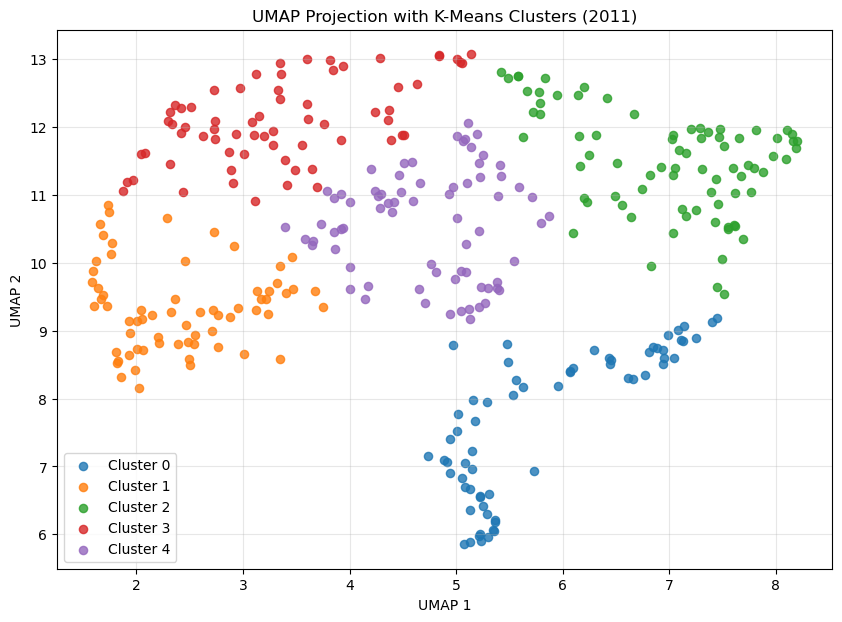

   area_code          area_name     umap1      umap2  umap_cluster  \
0  E06000047   County Durham UA  7.655542  11.830118             2   
1  E06000005      Darlington UA  6.226030  10.896845             2   
2  E06000001      Hartlepool UA  7.765077  11.041337             2   
3  E06000002   Middlesbrough UA  7.611456  10.548906             2   
4  E06000048  Northumberland UA  5.629399  11.849780             2   

   pct_very_good  pct_good  pct_fair  pct_bad  pct_very_bad  ...  \
0           42.4      33.4      16.1      6.3           1.8  ...   
1           44.6      35.2      14.3      4.5           1.4  ...   
2           43.3      32.7      15.9      6.3           1.8  ...   
3           45.4      32.7      14.2      5.8           1.8  ...   
4           44.0      34.3      15.4      4.9           1.4  ...   

   pct_shared_ownership  pct_social_rented_total  pct_social_rented_council  \
0                   0.2                     20.1                       12.8   
1           

In [28]:
# Now apply UMAP
import umap
import matplotlib.pyplot as plt


umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    init='spectral',
    random_state=42
)

umap_proj = umap_model.fit_transform(X_scaled)

# applying kmeans on UMAP cordinates
kmeans_model = KMeans(n_clusters = 5, random_state=42, n_init=10)
umap_clusters = kmeans_model.fit_predict(umap_proj)

print("\nCluster counts:")
print(pd.Series(umap_clusters).value_counts().sort_index())

plt.figure(figsize=(10,7))

for cluster_id in sorted(pd.Series(umap_clusters).unique()):
    cluster_points = umap_proj[umap_clusters == cluster_id]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        s=35,
        alpha=0.8,
        label=f'Cluster {cluster_id}'
    )

plt.title('UMAP Projection with K-Means Clusters (2011)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# save output for Tableau
umap_kmeans_df = pd.DataFrame({
    'area_code': area_info['area_code'],
    'area_name': area_info['area_name'],
    'umap1': umap_proj[:,0],
    'umap2': umap_proj[:,1],
    'umap_cluster': umap_clusters
})


# keep all percentage variables
for col in feature_cols:
    umap_kmeans_df[col] = df[col]

print(umap_kmeans_df.head())
umap_kmeans_output = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\projection_2011_umap_kmeans.csv"
umap_kmeans_df.to_csv(umap_kmeans_output, index=False)

print("\nSaved UMAP + KMeans output to:")
print(umap_kmeans_output)

t-SNE on 2011 dataset

c:\conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



Cluster counts:
0     71
1     52
2     38
3     85
4    102
Name: count, dtype: int64


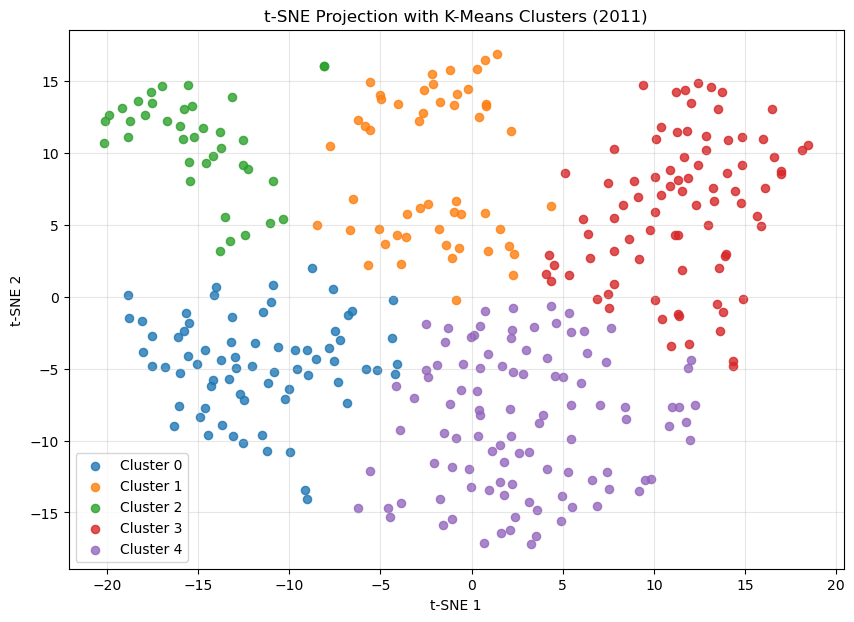

   area_code          area_name      tsne1      tsne2  tsne_cluster  \
0  E06000047   County Durham UA  12.401146   9.155025             3   
1  E06000005      Darlington UA   7.794855   3.156996             3   
2  E06000001      Hartlepool UA  14.829823  11.116568             3   
3  E06000002   Middlesbrough UA  16.010530  10.937703             3   
4  E06000048  Northumberland UA   7.648440  -2.185083             4   

   pct_very_good  pct_good  pct_fair  pct_bad  pct_very_bad  ...  \
0           42.4      33.4      16.1      6.3           1.8  ...   
1           44.6      35.2      14.3      4.5           1.4  ...   
2           43.3      32.7      15.9      6.3           1.8  ...   
3           45.4      32.7      14.2      5.8           1.8  ...   
4           44.0      34.3      15.4      4.9           1.4  ...   

   pct_shared_ownership  pct_social_rented_total  pct_social_rented_council  \
0                   0.2                     20.1                       12.8   
1     

In [29]:
#t-SNE + KMeans clustering (2011) 

tsne_model = TSNE(
    n_components = 2,
    perplexity = 30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

tsne_proj = tsne_model.fit_transform(X_scaled)

kmeans_model_tsne = KMeans(n_clusters=5, random_state=42, n_init=10)
tsne_clusters = kmeans_model_tsne.fit_predict(tsne_proj)
print("\nCluster counts:")
print(pd.Series(tsne_clusters).value_counts().sort_index())

plt.figure(figsize=(10,7))

for cluster_id in sorted(pd.Series(tsne_clusters).unique()):
    cluster_points = tsne_proj[tsne_clusters == cluster_id]
    plt.scatter(
        cluster_points[:,0],
        cluster_points[:,1],
        s=35,
        alpha=0.8,
        label=f'Cluster {cluster_id}'
    )
plt.title('t-SNE Projection with K-Means Clusters (2011)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

tsne_kmeans_df = pd.DataFrame({
    'area_code': area_info['area_code'],
    'area_name': area_info['area_name'],
    'tsne1': tsne_proj[:, 0],
    'tsne2': tsne_proj[:, 1],
    'tsne_cluster': tsne_clusters
})

for col  in feature_cols:
    tsne_kmeans_df[col] = df[col]
print(tsne_kmeans_df.head())

tsne_kmeans_output = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\projection_2011_tsne_kmeans.csv"
tsne_kmeans_df.to_csv(tsne_kmeans_output, index=False)

print("\nSaved t-SNE + KMeans output to:")
print(tsne_kmeans_output)

UMAP + KMeans on comparison dataset

c:\conda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(



Cluster counts:
0    132
1    136
2    117
3    112
4    137
Name: count, dtype: int64


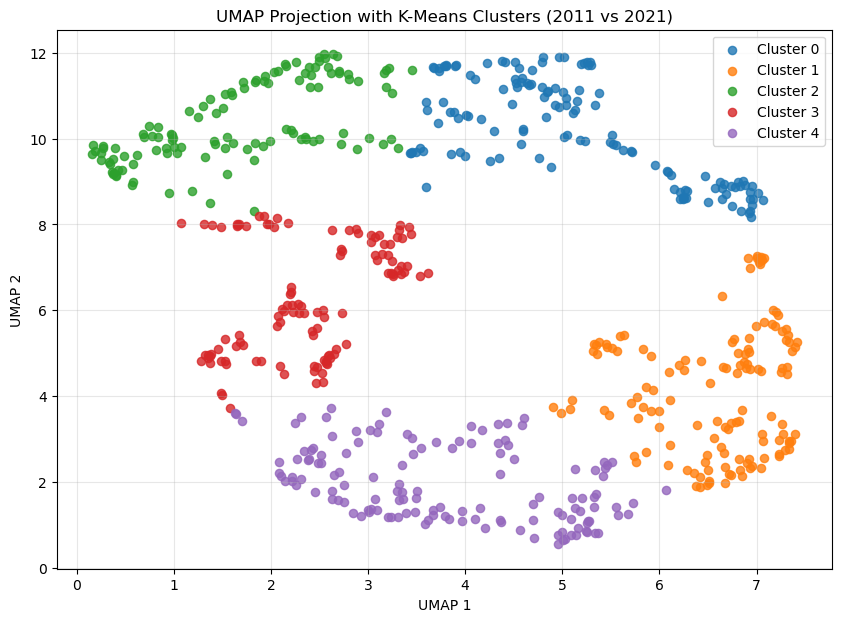

   year  area_code                area_name     umap1      umap2  \
0  2011  E06000001            Hartlepool UA  6.502212   8.529685   
1  2011  E06000002         Middlesbrough UA  6.272792   8.607414   
2  2011  E06000003  Redcar and Cleveland UA  6.644855   8.601396   
3  2011  E06000004      Stockton-on-Tees UA  4.760906   9.537626   
4  2011  E06000005            Darlington UA  4.827624  10.493268   

   umap_cluster  pct_very_good  pct_good  pct_fair  pct_bad  pct_very_bad  \
0             0           43.3      32.7      15.9      6.3           1.8   
1             0           45.4      32.7      14.2      5.8           1.8   
2             0           42.4      33.9      15.9      6.1           1.8   
3             0           46.3      33.5      13.8      4.9           1.5   
4             0           44.6      35.2      14.3      4.5           1.4   

   pct_bad_or_very_bad  pct_unemployed_of_total  pct_retired  \
0                  8.1                 7.774984         15.9   


In [30]:
# UMAP + KMeans clustering (2011 vs 2021 comparison)

# load comparison file
df_compare = pd.read_csv(r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\comparison_combined_health_econ.csv")

feature_cols_compare = [col for col in df_compare.columns if col.startswith("pct_")]
X_compare = df_compare[feature_cols_compare].copy()

scaler_compare = StandardScaler()
X_compare_scaled = scaler_compare.fit_transform(X_compare)

area_info_compare = df_compare[['year', 'area_code', 'area_name']].copy()


umap_model_compare = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    init='spectral',
    random_state=42
)

umap_proj_compare = umap_model_compare.fit_transform(X_compare_scaled)

kmeans_model_compare = KMeans(n_clusters=5, random_state=42, n_init=10)
umap_clusters_compare = kmeans_model_compare.fit_predict(umap_proj_compare)

print("\nCluster counts:")
print(pd.Series(umap_clusters_compare).value_counts().sort_index())

plt.figure(figsize=(10, 7))

for cluster_id in sorted(pd.Series(umap_clusters_compare).unique()):
    cluster_points = umap_proj_compare[umap_clusters_compare == cluster_id]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        s=35,
        alpha=0.8,
        label=f'Cluster {cluster_id}'
    )

plt.title('UMAP Projection with K-Means Clusters (2011 vs 2021)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

umap_compare_kmeans_df = pd.DataFrame({
    'year': area_info_compare['year'],
    'area_code': area_info_compare['area_code'],
    'area_name': area_info_compare['area_name'],
    'umap1': umap_proj_compare[:, 0],
    'umap2': umap_proj_compare[:, 1],
    'umap_cluster': umap_clusters_compare
})

for col in feature_cols_compare:
    umap_compare_kmeans_df[col] = df_compare[col]

print(umap_compare_kmeans_df.head())

umap_compare_output = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\projection_compare_umap_kmeans.csv"
umap_compare_kmeans_df.to_csv(umap_compare_output, index=False)

print("\nSaved comparison UMAP + KMeans output to:")
print(umap_compare_output)


t-SNE + KMeans on comparison dataset

c:\conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(



Cluster counts:
0    135
1    129
2    136
3    105
4    129
Name: count, dtype: int64


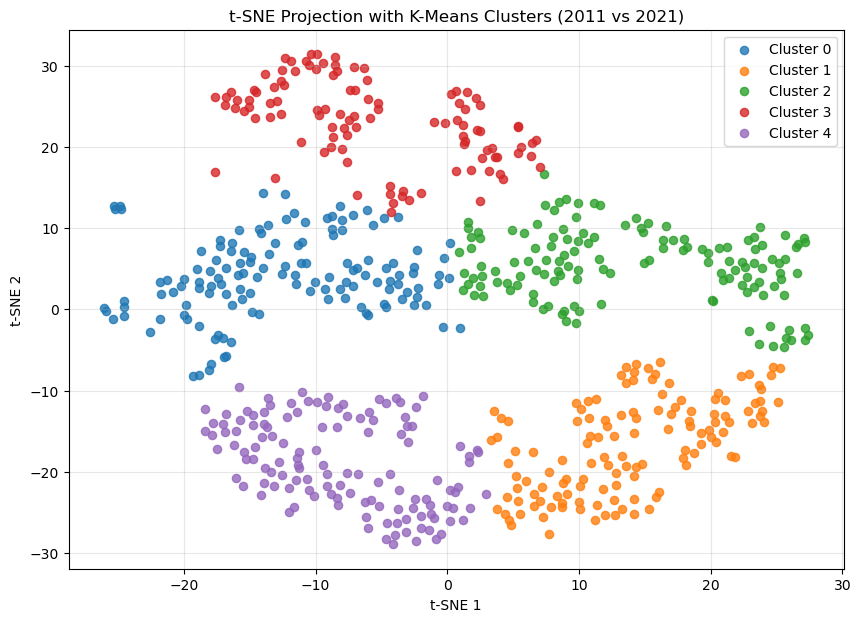

   year  area_code                area_name      tsne1      tsne2  \
0  2011  E06000001            Hartlepool UA  26.584650   4.429162   
1  2011  E06000002         Middlesbrough UA  25.631342   9.096536   
2  2011  E06000003  Redcar and Cleveland UA  25.271835   4.442959   
3  2011  E06000004      Stockton-on-Tees UA  11.596146  12.849938   
4  2011  E06000005            Darlington UA   8.819101   9.832992   

   tsne_cluster  pct_very_good  pct_good  pct_fair  pct_bad  pct_very_bad  \
0             2           43.3      32.7      15.9      6.3           1.8   
1             2           45.4      32.7      14.2      5.8           1.8   
2             2           42.4      33.9      15.9      6.1           1.8   
3             2           46.3      33.5      13.8      4.9           1.5   
4             2           44.6      35.2      14.3      4.5           1.4   

   pct_bad_or_very_bad  pct_unemployed_of_total  pct_retired  \
0                  8.1                 7.774984         15

In [ ]:
tsne_model_compare = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

tsne_proj_compare = tsne_model_compare.fit_transform(X_compare_scaled)

kmeans_model_compare = KMeans(n_clusters=5, random_state=42, n_init=10)
tsne_clusters_compare = kmeans_model_compare.fit_predict(tsne_proj_compare)

print("\nCluster counts:")
print(pd.Series(tsne_clusters_compare).value_counts().sort_index())

plt.figure(figsize=(10, 7))

for cluster_id in sorted(pd.Series(tsne_clusters_compare).unique()):
    cluster_points = tsne_proj_compare[tsne_clusters_compare == cluster_id]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        s=35,
        alpha=0.8,
        label=f'Cluster {cluster_id}'
    )

plt.title('t-SNE Projection with K-Means Clusters (2011 vs 2021)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

tsne_compare_kmeans_df = pd.DataFrame({
    'year': area_info_compare['year'],
    'area_code': area_info_compare['area_code'],
    'area_name': area_info_compare['area_name'],
    'tsne1': tsne_proj_compare[:, 0],
    'tsne2': tsne_proj_compare[:, 1],
    'tsne_cluster': tsne_clusters_compare
})

for col in feature_cols_compare:
    tsne_compare_kmeans_df[col] = df_compare[col]

print(tsne_compare_kmeans_df.head())

tsne_compare_output = r"C:\MSC\TB-2\Visual Analytics\coursework\datasets\projection_compare_tsne_kmeans.csv"
tsne_compare_kmeans_df.to_csv(tsne_compare_output, index=False)

print("\nSaved comparison t-SNE + KMeans output to:")
print(tsne_compare_output)